# 12 · PD lifetime, ELBE e CCF — a perda esperada ponta a ponta

`yggdrasil.credit_risk.ecl` traz os **parâmetros de risco da perda esperada** e a conta
que os junta na provisão de IFRS 9 / Resolução CMN 4.966/2021.

É o eixo que faltava no pacote:

| eixo | módulo | o que faz |
|---|---|---|
| transversal | `tree` / `model` | **ordena** o risco entre clientes (12 meses) |
| temporal / macro | `econometric` | **desloca o nível** conforme o ciclo |
| perda inesperada | `capital` | capital econômico da carteira |
| **perda esperada** | **`ecl`** | **quando** a perda acontece, **quanto** sobra no que já quebrou, **sobre qual exposição** |

Roteiro deste tutorial:

1. o painel de contratos (contrato de dados)
2. a curva de PD e as suas **quatro representações**
3. os **cinco motores** de PD lifetime
4. as duas pontes: **calibrar o nível** e **condicionar ao ciclo**
5. escorar a carteira e **testar** a curva
6. **ELBE** — a perda dos contratos já em *default*
7. **CCF/EAD** — a conversão do limite não sacado
8. a montagem do **ECL** e os cenários
9. governança: gráficos e MLflow

| aprofundamento por módulo | |
|---|---|
| [`13`](13_tutorial_pd_lifetime.ipynb) | **PD lifetime** — censura, as 4 representações da curva, os 5 motores, calibração de nível e condicionamento ao ciclo |
| [`14`](14_tutorial_elbe.ipynb) | **ELBE** — coorte variável, horizonte de *workout*, desconto, *add-on* e LGD *in default* |
| [`15`](15_tutorial_ccf.ipynb) | **CCF/EAD** — os 3 desenhos de base, as 4 medidas, higiene, bimodalidade, backtest e a ponte com o `ModelSegmenter` |

Este notebook é a **visão de conjunto**: percorre os três parâmetros e fecha na tabela de
ECL. Cada um deles tem um tutorial próprio, mais fundo, na tabela acima.

> Metodologia (o *porquê*): [`docs/credit-risk/ecl.md`](../../docs/credit-risk/ecl.md).

In [1]:
# --- Bootstrap: torna o pacote `yggdrasil` importável a partir do repositório,
# sem `pip install`. Procura a raiz do repo (a pasta que contém `yggdrasil/`) por
# vários âncoras — o caminho do próprio notebook (VS Code expõe `__vsc_ipynb_file__`),
# o diretório atual, os diretórios do sys.path e, no Databricks, o caminho via
# dbutils — subindo até achá-la, e a insere no sys.path. Cobre Jupyter/VS Code
# local e Databricks; se o pacote já estiver importável, é inócuo.
import sys
from pathlib import Path

def _find_yggdrasil_root():
    _anchors = []
    for _n in ("__vsc_ipynb_file__", "__file__", "__session__"):
        _v = globals().get(_n)
        if _v:
            _anchors.append(Path(str(_v)))
    _anchors.append(Path.cwd())
    _anchors += [Path(_p) for _p in sys.path if _p not in ("", ".")]
    for _a in _anchors:
        try:
            _a = _a.resolve()
        except Exception:
            continue
        for _b in (_a, *_a.parents):
            if (_b / "yggdrasil" / "__init__.py").is_file():
                return _b
    try:  # fallback Databricks: caminho do próprio notebook
        _nbp = (dbutils.notebook.entry_point.getDbutils()  # noqa: F821
                .notebook().getContext().notebookPath().get())
        for _pref in ("/Workspace", ""):
            for _b in Path(_pref + _nbp).parents:
                if (_b / "yggdrasil" / "__init__.py").is_file():
                    return _b
    except Exception:
        pass
    return None

_ygg_root = _find_yggdrasil_root()
if _ygg_root and str(_ygg_root) not in sys.path:
    sys.path.insert(0, str(_ygg_root))

In [2]:
%matplotlib inline
import os
os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")   # MLflow 3.x local (seção 9)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 30)

---
## 1 · O painel de contratos

Todo o eixo *lifetime* parte do mesmo objeto: um painel **longo** com uma linha por
contrato × safra de observação, onde cada linha diz *quantos meses o contrato tem de
vida* (a idade, ou *months on book*) e *se ele quebrou naquele período*.

Aqui geramos uma carteira sintética com dois produtos, **maturação** (o risco cresce com
a idade), rating, prazo remanescente e as colunas de rotativo (sacado/limite) que a parte
de CCF vai usar.

In [3]:
def carteira_sintetica(n=1200, seed=42):
    rng = np.random.default_rng(seed)
    base_h = {"cartao": 0.014, "consignado": 0.004}
    mult_rating = {"A": 0.6, "B": 1.0, "C": 1.8}
    linhas = []
    for i in range(n):
        produto = "cartao" if rng.uniform() < 0.5 else "consignado"
        rating = str(rng.choice(["A", "B", "C"], p=[0.5, 0.3, 0.2]))
        origem = pd.Timestamp("2020-01-01") + pd.DateOffset(months=int(rng.integers(0, 18)))
        prazo, limite = int(rng.integers(12, 49)), float(rng.lognormal(8.5, 0.5))
        sacado = limite * float(rng.beta(2.0, 3.0))
        for t in range(36):
            h = base_h[produto] * mult_rating[rating] * (1.0 + t / 20.0)   # maturação
            quebrou = int(rng.uniform() < min(h, 0.9))
            linhas.append((f"C{i:05d}", origem + pd.DateOffset(months=t), origem, quebrou,
                           produto, rating, max(prazo - t, 0), sacado, limite))
            if quebrou:
                break
            sacado = float(np.clip(sacado * (1 + rng.normal(0.012 + 2 * h, 0.05)), 0, limite))
    return pd.DataFrame(linhas, columns=[
        "id_contrato", "dt_ref", "safra_origem", "default", "produto", "rating",
        "prazo", "sacado", "limite"])

df = carteira_sintetica()
print(df.shape)
df.head(3)

(35424, 9)


,id_contrato,dt_ref,safra_origem,default,produto,rating,prazo,sacado,limite
0,C00000,2020-08-01,2020-08-01,0,consignado,A,43,3228.209967,7865.822271
1,C00000,2020-09-01,2020-08-01,0,consignado,A,42,3407.987678,7865.822271
2,C00000,2020-10-01,2020-08-01,0,consignado,A,41,3658.140995,7865.822271


In [4]:
from yggdrasil.credit_risk.ecl import ContractPanel

painel = ContractPanel(
    df,
    id_col="id_contrato", date_col="dt_ref", default_col="default",
    origin_col="safra_origem",     # a idade é derivada daqui
    segment_col="produto",
    term_col="prazo",
)
painel

ContractPanel(n_obs=35424, n_contratos=1200, idade_max=35, freq='M')

In [5]:
painel.summary().T

,0
n_obs,35424
n_contratos,1200
n_defaults,447
taxa_default_contratos,0.3725
idade_min,0
idade_max,35
safra_min,2020-01-01 00:00:00
safra_max,2024-05-01 00:00:00
n_segmentos,2
obs_pos_default_descartadas,0


### A tabela de vida: base em risco, quebras e **censura**

O ponto delicado é a censura. Um contrato originado há 6 meses não é um contrato que
sobreviveu 60 meses — ele apenas **ainda não foi observado até lá**. Somar os dois na
mesma taxa subestima o risco das idades altas.

Por isso a base em risco é recontada **idade a idade**, e a tabela separa quem saiu por
*default* de quem saiu por fim de janela (`n_censurado`).

In [6]:
vida = painel.at_risk()
vida.head(8)

,n_em_risco,n_default,n_censurado,hazard
idade,,,,
0,1200,10,0,0.008333
1,1190,14,0,0.011765
2,1176,9,0,0.007653
3,1167,17,0,0.014567
4,1150,12,0,0.010435
5,1138,16,0,0.014060
6,1122,9,0,0.008021
7,1113,5,0,0.004492


In [7]:
# Todo contrato sai exatamente uma vez: por default ou por censura.
total_saidas = int(vida["n_default"].sum() + vida["n_censurado"].sum())
print(f"{total_saidas} saídas para {painel.n_contracts} contratos")

1200 saídas para 1200 contratos


---
## 2 · A curva de PD — quatro nomes para a mesma coisa

A maior fonte de erro em PD *lifetime* não é o motor de estimação: é o **vocabulário**.
A mesma curva é pedida de quatro formas, e cada área usa uma.

| representação | responde |
|---|---|
| **condicional** (*hazard*) | "sobreviveu até `t−1`; qual a chance de quebrar em `t`?" |
| **marginal** | "qual a chance de quebrar **exatamente** em `t`?" (vista de hoje) |
| **acumulada** | "qual a chance de ter quebrado **até** `t`?" |
| **sobrevivência** | "qual a chance de **não** ter quebrado até `t`?" |

`PDCurve` guarda o *hazard* e entrega as outras três — e aceita ser construída a partir
de **qualquer uma** delas. É ali que nascem os erros de um período de defasagem.

In [8]:
from yggdrasil.credit_risk.ecl import PDCurve, constant_hazard

# O caminho mais curto: só a PD de 12 meses que já saiu do scorecard.
curva = constant_hazard(pd_12m=0.06, horizon=36)
curva

PDCurve(H=36, freq='M', PD12m=6.0000%, PDlife=16.9416%)

In [9]:
curva.to_frame().head(6)

,pd_condicional,pd_marginal,pd_acumulada,sobrevivencia
horizonte,,,,
1,0.005143,0.005143,0.005143,0.994857
2,0.005143,0.005117,0.010260,0.989740
3,0.005143,0.005090,0.015350,0.984650
4,0.005143,0.005064,0.020414,0.979586
5,0.005143,0.005038,0.025452,0.974548
6,0.005143,0.005012,0.030464,0.969536


In [10]:
# As quatro representações carregam a MESMA informação — a ida e a volta é exata.
for nome, serie in [("marginal", curva.marginal()),
                    ("acumulada", curva.cumulative()),
                    ("sobrevivência", curva.survival())]:
    reconstruida = getattr(PDCurve, {"marginal": "from_marginal",
                                     "acumulada": "from_cumulative",
                                     "sobrevivência": "from_survival"}[nome])(serie)
    print(f"{nome:14s} -> hazard idêntico: {np.allclose(reconstruida.hazard_, curva.hazard_)}")

marginal       -> hazard idêntico: True
acumulada      -> hazard idêntico: True
sobrevivência  -> hazard idêntico: True


> **O ECL soma a marginal.** Usar a condicional na soma conta o mesmo contrato várias
> vezes; usar a acumulada conta a mesma perda repetidamente. Só a marginal particiona a
> probabilidade entre os períodos.

`forward(t0, t1)` dá a PD condicional **entre horizontes** — o insumo quantitativo
natural do SICR: comparar a PD *lifetime* remanescente de hoje com a da originação.

In [11]:
print(f"PD 12m ............... {curva.pd_12m():.4%}")
print(f"PD lifetime (36m) .... {curva.pd_lifetime():.4%}")
print(f"PD lifetime até 24m .. {curva.pd_lifetime(24):.4%}")
print(f"PD forward (12 -> 36) . {curva.forward(12, 36):.4%}   <- quem sobreviveu 12 meses")

PD 12m ............... 6.0000%
PD lifetime (36m) .... 16.9416%
PD lifetime até 24m .. 11.6400%
PD forward (12 -> 36) . 11.6400%   <- quem sobreviveu 12 meses


---
## 3 · Os cinco motores de PD lifetime

`LifetimePD(method=...)` — **uma** classe, o comportamento escolhido por argumento (o
mesmo padrão do `task_type` dos segmentadores). Todos devolvem a mesma `PDCurve`.

| `method` | o que faz |
|---|---|
| `"constant"` | *hazard* constante a partir da PD de 12 meses — a linha de base |
| `"vintage"` | taxa marginal observada **por idade**, com a base em risco recontada |
| `"km"` | Kaplan-Meier — mesmo ponto estimado, mais Greenwood e IC log-log |
| `"hazard"` | regressão de *hazard* em tempo discreto: curva **por contrato** |
| `"markov"` | cadeia de Markov sobre a matriz de transição: curva **por rating** |

In [12]:
from yggdrasil.credit_risk.ecl import LifetimePD

comparacao = {}
for metodo in ["constant", "vintage", "km"]:
    lt = LifetimePD(method=metodo, horizon=48).fit(painel, by="produto")
    comparacao[metodo] = lt.summary().assign(metodo=metodo)

pd.concat(comparacao.values(), ignore_index=True)[
    ["metodo", "grupo", "pd_12m", "pd_lifetime"]].round(4)

,metodo,grupo,pd_12m,pd_lifetime
0,constant,cartao,0.1675,0.5197
1,constant,consignado,0.0690,0.2486
2,vintage,cartao,0.1675,0.6445
3,vintage,consignado,0.0690,0.3186
4,km,cartao,0.1675,0.6445
5,km,consignado,0.0690,0.3186


Repare: `constant` e `vintage` batem na PD de 12 meses (por construção) mas divergem no
*lifetime* — porque a curva de safra **enxerga a maturação** e a constante não.

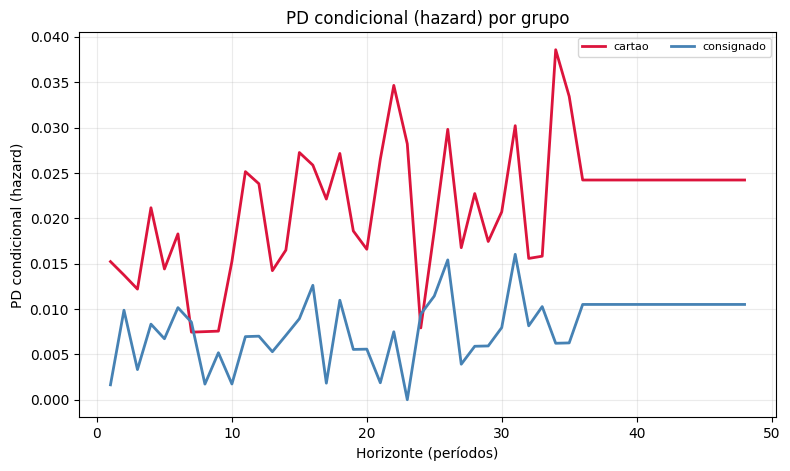

In [13]:
lt = LifetimePD(method="vintage", horizon=48).fit(painel, by="produto")
fig = lt.plot("hazard")   # o hazard sobe com a idade: é a maturação

### Kaplan-Meier: o mesmo ponto estimado, mais a **incerteza**

Em tempo discreto o KM e a curva de safra dão o mesmo *hazard*. O que o KM acrescenta é
o erro padrão de **Greenwood** e o IC log-log — que é o que vai para a documentação.

KM == curva de safra no ponto estimado: True


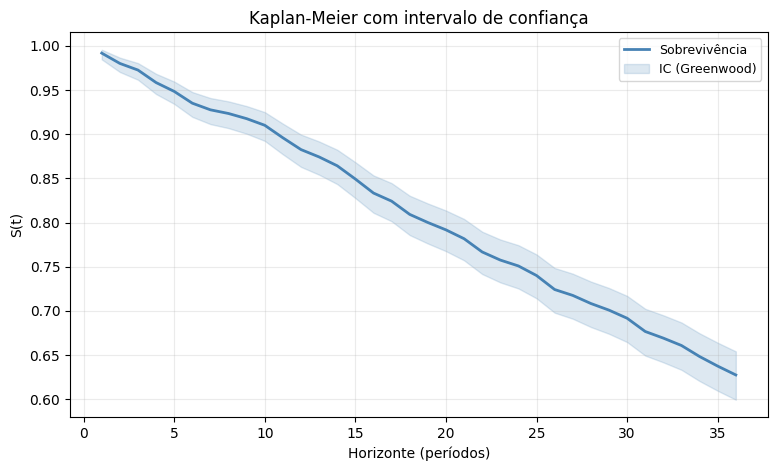

In [14]:
from yggdrasil.credit_risk.ecl import kaplan_meier, report, vintage_curve

km, tabela_km = kaplan_meier(painel, return_table=True)
print("KM == curva de safra no ponto estimado:",
      np.allclose(km.hazard_, vintage_curve(painel, fill="zero").hazard_))
fig = report.plot_survival_ci(tabela_km)

### Hazard em tempo discreto: curva **por contrato**

Expande o painel em pessoa-período e ajusta um modelo binário para "quebrou neste
período, dado que chegou vivo nele". A idade entra como *baseline* (dummies, spline,
linear ou log) e as covariáveis deslocam essa linha.

Duas virtudes: a curva passa a ser **por contrato** (o que o ECL por contrato exige) e
covariáveis que mudam no tempo entram naturalmente.

In [15]:
from yggdrasil.credit_risk.ecl import DiscreteHazard

painel_feat = ContractPanel(
    painel.df.assign(feat_score=painel.df["rating"].map({"A": -1.0, "B": 0.0, "C": 1.0})),
    origin_col="safra_origem", segment_col="produto", drop_post_default=False,
)
mh = DiscreteHazard(baseline="spline").fit(painel_feat, features=["feat_score"])
mh.coef_frame().round(4)

,termo,coeficiente,odds_ratio
0,(intercepto),-3.6426,0.0262
1,spline_0,-0.1147,0.8916
2,spline_1,-0.8135,0.4433
3,spline_2,-1.0474,0.3508
4,spline_3,-0.3708,0.6902
5,spline_4,-0.4702,0.6249
6,spline_5,-0.5255,0.5913
7,spline_6,-0.2718,0.7620
8,feat_score,0.4921,1.6358


In [16]:
for score, rotulo in [(-1.0, "rating A"), (0.0, "rating B"), (1.0, "rating C")]:
    c = mh.predict_curve([score], horizon=48)
    print(f"{rotulo}: PD 12m = {c.pd_12m():.4%} | PD lifetime = {c.pd_lifetime():.4%}")

rating A: PD 12m = 8.0132% | PD lifetime = 37.7503%
rating B: PD 12m = 12.7443% | PD lifetime = 53.8318%
rating C: PD 12m = 19.9244% | PD lifetime = 71.5673%


### Markov: curva por **rating**, reusando o motor de capital

A estimação da matriz e o z-shift já existiam em `credit_risk.capital.migration` e são
chamados daqui — **uma única fórmula de migração no repositório**. A PD acumulada em `t`
períodos de quem está no rating `i` é `(Mᵗ)[i, default]`.

In [17]:
from yggdrasil.credit_risk.ecl import MarkovPD

mk = MarkovPD().fit(painel, rating_col="rating")
display(mk.matrix_frame().round(4))
mk.pd_by_rating((12, 24, 36, 48)).round(4)

para,A,B,C,D
de,,,,
A,0.9911,0.0000,0.0000,0.0089
B,0.0000,0.9853,0.0000,0.0147
C,0.0000,0.0000,0.9767,0.0233
D,0.0000,0.0000,0.0000,1.0000


,rating,pd_12p,pd_24p,pd_36p,pd_48p
0,A,0.1019,0.1934,0.2756,0.3494
1,B,0.1627,0.2989,0.4130,0.5085
2,C,0.2463,0.4320,0.5719,0.6774


---
## 4 · As duas pontes: nível e ciclo

### `calibrate_to` — o **nível** vem do modelo transversal

A curva empírica dá a **forma** da maturação; o scorecard dá o **nível** por cliente.
`calibrate_to` resolve o deslocamento no logit do *hazard* até a PD acumulada bater com
o alvo, **preservando o formato**. É a prática de mercado.

In [18]:
alvos = {"cartao": 0.095, "consignado": 0.024}         # viriam do ModelSegmenter
lt_cal = lt.calibrate_to(alvos)

pd.DataFrame({
    "antes": lt.summary().set_index("grupo")["pd_12m"],
    "alvo": pd.Series(alvos),
    "depois": lt_cal.summary().set_index("grupo")["pd_12m"],
}).round(5)

,antes,alvo,depois
cartao,0.16751,0.095,0.095
consignado,0.06897,0.024,0.024


In [19]:
# O FORMATO não muda: é um deslocamento uniforme no logit.
antes, depois = lt.curve("cartao").hazard_, lt_cal.curve("cartao").hazard_
print("ordem dos hazards preservada:", np.array_equal(np.argsort(antes), np.argsort(depois)))
lt_cal.curve("cartao").meta["calibracao"]

ordem dos hazards preservada: True


{'alvo': 0.095, 'horizonte': 12, 'delta': -0.6119670314108737}

### `condition` — o **ciclo** desloca a curva (forward-looking)

`condition(z, rho)` leva a curva de TTC a PIT pelo arcabouço de Vasicek, com a convenção
de sinal do repositório: **`z > 0` = ciclo benigno**.

O padrão (`mode="shift"`) é o deslocamento puro do limiar — **idempotente em `z = 0`** e
consistente com o `zshift_transition_matrix` do motor de capital. O `mode="conditional"`
é a lei condicional exata do fator único, que fecha com `capital.asrf.conditional_pd` e
com a inversa `econometric.transforms.vasicek_z`.

`decay` é a **reversão à média**: num horizonte *lifetime*, o choque de hoje não vale
para sempre.

In [20]:
cenarios = {
    "otimista": lt_cal.condition(z=+1.0, rho=0.10),
    "base": lt_cal,
    "adverso": lt_cal.condition(z=-1.5, rho=0.10),
    "adverso c/ reversão": lt_cal.condition(z=-1.5, rho=0.10, decay=0.10),
}
pd.DataFrame({
    nome: {"PD 12m": m.curve("cartao").pd_12m(), "PD lifetime": m.curve("cartao").pd_lifetime()}
    for nome, m in cenarios.items()
}).T.round(4)

,PD 12m,PD lifetime
otimista,0.0397,0.2109
base,0.0950,0.4310
adverso,0.2803,0.8295
adverso c/ reversão,0.1912,0.5138


In [21]:
from yggdrasil.credit_risk.ecl import pit_from_ttc
from yggdrasil.credit_risk.capital.asrf import conditional_pd
from scipy.stats import norm

rho, q = 0.12, 0.999
print("shift é idempotente em z=0 ...:", np.isclose(pit_from_ttc(0.05, rho, 0.0), 0.05))
print("conditional bate com o capital:",
      np.isclose(pit_from_ttc(0.05, rho, -norm.ppf(q), mode="conditional"),
                 float(conditional_pd(0.05, rho, q))))

shift é idempotente em z=0 ...: True
conditional bate com o capital: True


---
## 5 · Escorar a carteira e testar a curva

`apply` cola a estrutura a termo em cada contrato, respeitando a **idade** atual (a curva
começa dali) e o **prazo** remanescente (zera as marginais além dele).

In [22]:
carteira = df.groupby("id_contrato").tail(1).copy()
carteira["idade"] = (pd.PeriodIndex(carteira["dt_ref"], freq="M").asi8
                     - pd.PeriodIndex(carteira["safra_origem"], freq="M").asi8)
rng = np.random.default_rng(7)
carteira["saldo"] = rng.lognormal(9.0, 0.5, len(carteira))
carteira["lgd"] = np.where(carteira["produto"] == "cartao", 0.75, 0.35)
carteira["taxa_efetiva"] = np.where(carteira["produto"] == "cartao", 2.5, 0.25)
carteira["estagio"] = rng.choice([1, 2, 3], len(carteira), p=[0.72, 0.18, 0.10])
carteira["meses_em_default"] = rng.integers(0, 30, len(carteira))

escorada = lt_cal.apply(carteira, age_col="idade", term_col="prazo", detail=True)
escorada[["produto", "idade", "prazo", "pd_12m", "pd_lifetime"]].head(5).round(5)

,produto,idade,prazo,pd_12m,pd_lifetime
35,consignado,35,8,0.02834,0.02834
71,cartao,35,3,0.03932,0.03932
107,consignado,35,7,0.02484,0.02484
143,consignado,35,0,0.00000,0.00000
179,consignado,35,0,0.00000,0.00000


In [23]:
# Identidade: a soma das marginais É a PD lifetime, e as 12 primeiras são a PD de 12m.
marg = [c for c in escorada.columns if c.startswith("pd_marg_h")]
print("Σ marginais == pd_lifetime:", np.allclose(escorada[marg].sum(axis=1), escorada["pd_lifetime"]))
print("prazo trunca a curva:",
      np.allclose(escorada.loc[escorada["prazo"] <= 5,
                               [f"pd_marg_h{t}" for t in range(6, 49)]].to_numpy(), 0.0))

Σ marginais == pd_lifetime: True
prazo trunca a curva: True


### Backtest: previsto × observado, com o IC de Greenwood

Aqui rodamos em amostra (bate exatamente); na prática o painel do backtest é a janela
*out-of-time*. A coluna `dentro_do_ic` é o veredito por horizonte.

,grupo,horizonte,n_em_risco_inicial,pd_prevista,pd_observada,ic_inf,ic_sup,erro_absoluto,erro_relativo,dentro_do_ic
0,cartao,12,591,0.1675,0.1675,0.1397,0.2001,0.0,0.0,True
1,cartao,24,591,0.3638,0.3638,0.3264,0.4040,0.0,0.0,True
2,cartao,36,591,0.5228,0.5228,0.4832,0.5636,0.0,0.0,True
3,consignado,12,609,0.0690,0.0690,0.0514,0.0922,0.0,0.0,True
4,consignado,24,609,0.1379,0.1379,0.1129,0.1679,0.0,0.0,True
5,consignado,36,609,0.2266,0.2266,0.1954,0.2620,0.0,0.0,True


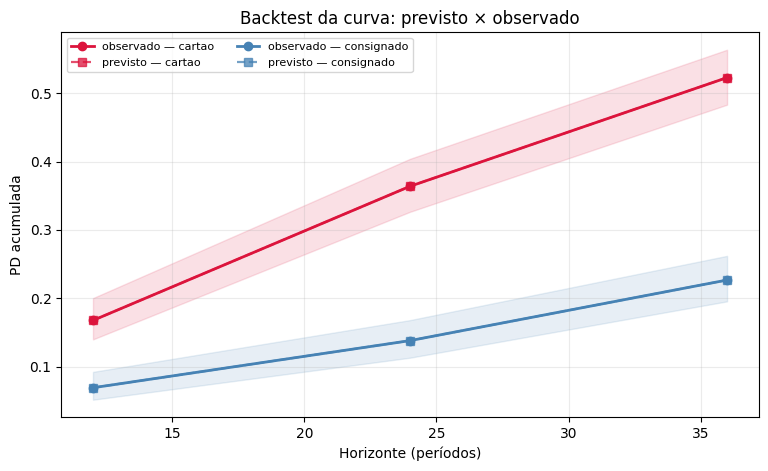

In [24]:
bt = lt.backtest(painel, horizons=(12, 24, 36))
display(bt.round(4))
fig = report.plot_backtest(bt)

---
## 6 · ELBE — a perda dos contratos **já em *default***

Para o contrato que não quebrou, a perda esperada é `PD × LGD × EAD`. Para o que **já
quebrou**, não há PD: o evento aconteceu. O que resta é *do saldo que ainda está lá,
quanto ainda vira perda?*

A construção parte de duas coisas — a **exposição inicial** (o EAD na data do *default*)
e as **colunas de LGD por mês em *default***, com `lgd(t) = 1 − r(t)`.

In [25]:
def defaults_sinteticos(n=600, meses=37, seed=5):
    rng = np.random.default_rng(seed)
    segmento = np.where(rng.uniform(size=n) < 0.6, "cartao", "consignado")
    ead0 = rng.lognormal(8.5, 0.6, n)
    assintota = np.clip(np.where(segmento == "cartao", 0.25, 0.65) * rng.uniform(0.8, 1.2, n), 0, 0.95)
    velocidade = np.where(segmento == "cartao", 0.10, 0.18)
    t = np.arange(meses)
    r = assintota[:, None] * (1 - np.exp(-velocidade[:, None] * t[None, :]))
    r = np.where(t[None, :] < rng.integers(3, meses + 1, n)[:, None], r, np.nan)  # censura
    out = pd.DataFrame({"id_contrato": [f"D{i:04d}" for i in range(n)],
                        "segmento": segmento, "exposicao_inicial": ead0})
    for k in range(meses):
        out[f"lgd_m{k}"] = 1.0 - r[:, k]
    return out

defaults = defaults_sinteticos()
defaults[["id_contrato", "segmento", "exposicao_inicial", "lgd_m0", "lgd_m6", "lgd_m24"]].head(4).round(3)

,id_contrato,segmento,exposicao_inicial,lgd_m0,lgd_m6,lgd_m24
0,D0000,consignado,8958.737,1.0,0.643,NaN
1,D0001,consignado,2904.129,1.0,0.588,0.384
2,D0002,cartao,8470.177,1.0,0.882,0.762
3,D0003,cartao,4609.859,1.0,0.870,NaN


In [26]:
from yggdrasil.credit_risk.ecl import elbe_table

tab = elbe_table(defaults, exposure_col="exposicao_inicial", lgd_prefix="lgd_m",
                 kind="lgd", addon=0.05, discount_rate=0.18)
tab

ELBETable(T*=28, LGD=65.05%, ELBE(0)=65.05%, ELBE(T*)=100.00%)

In [27]:
tab.frame[["n_contratos", "recuperacao_acumulada", "exposicao_remanescente",
           "elbe", "lgd_in_default"]].iloc[[0, 3, 6, 12, 24, 36]].round(4)

,n_contratos,recuperacao_acumulada,exposicao_remanescente,elbe,lgd_in_default
mes_default,,,,,
0,600,0.0000,3.669423e+06,0.6505,0.7005
3,580,0.1355,3.172305e+06,0.7525,0.8025
6,534,0.2178,2.870160e+06,0.8317,0.8817
12,440,0.2994,2.570726e+06,0.9285,0.9785
24,236,0.3450,2.403323e+06,0.9932,1.0000
36,16,0.3538,2.371301e+06,1.0000,1.0000


Três coisas para ler nessa tabela:

- **`ELBE(0) = LGD do ciclo completo`** — no mês do *default* nada foi recuperado, então o
  que resta perder sobre o saldo remanescente é a LGD inteira;
- **a ELBE sobe** com o tempo em *default* mesmo com recuperação boa: o denominador
  (saldo remanescente) encolhe mais rápido que o numerador (perda final);
- **`n_contratos` cai** — é a censura. Cada mês é estimado nos contratos que
  **efetivamente chegaram** ali, encadeando a recuperação **marginal**. A média direta da
  acumulada misturaria coortes e a curva poderia até cair.

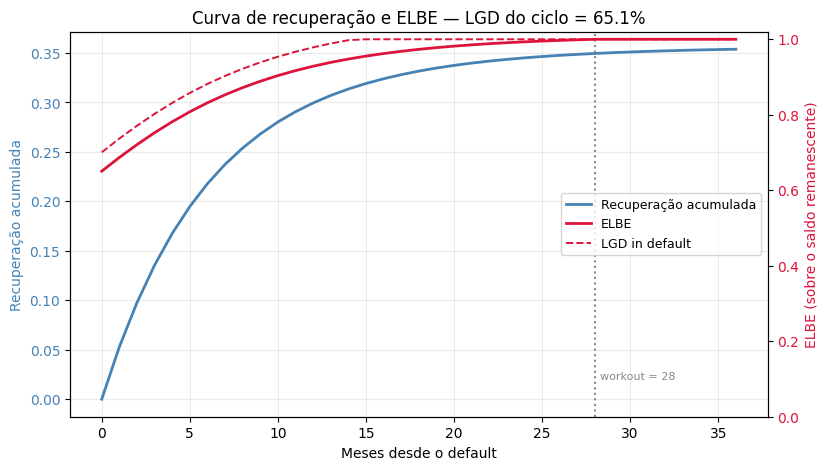

In [28]:
fig = tab.plot()

In [29]:
# Por segmento — agregar recuperações muito diferentes numa curva só é o erro clássico.
tabs = elbe_table(defaults, by="segmento", addon=0.05)
pd.DataFrame({seg: {"LGD do ciclo": t.lgd, "workout (meses)": t.workout,
                    "ELBE(0)": t.frame["elbe"].iloc[0]}
              for seg, t in tabs.items()}).T.round(4)

,LGD do ciclo,workout (meses),ELBE(0)
cartao,0.7629,31.0,0.7629
consignado,0.3496,27.0,0.3496


In [30]:
from yggdrasil.credit_risk.ecl import apply_elbe

carteira = apply_elbe(carteira, tabs, months_col="meses_em_default",
                      exposure_col="saldo", segment_col="produto")
carteira[["produto", "meses_em_default", "saldo", "elbe", "lgd_in_default",
          "perda_esperada"]].head(4).round(3)

,produto,meses_em_default,saldo,elbe,lgd_in_default,perda_esperada
35,consignado,9,8108.069,0.738,0.788,5982.958
71,cartao,16,9408.537,0.951,1.000,8950.538
107,consignado,18,7065.161,0.945,0.995,6674.752
143,consignado,6,5191.117,0.617,0.667,3202.863


---
## 7 · CCF / EAD — a conversão do limite não sacado

Em produto rotativo a exposição não é conhecida: o cliente decide quanto saca, e quem
está indo para o *default* costuma sacar mais.

$$EAD = sacado_{ref} + CCF \cdot (limite_{ref} - sacado_{ref})$$

O que mais move o resultado **não é o modelo**: é de qual **data de referência** se olha
o contrato.

In [31]:
from yggdrasil.credit_risk.ecl import reference_dataset

bases = {m: reference_dataset(df, method=m, horizon=12, segment_col="produto")
         for m in ("cohort", "fixed_horizon", "variable")}
pd.DataFrame({m: {"n observações": len(b),
                  "meses até o default (méd.)": b.frame["meses_ate_default"].mean(),
                  "CCF médio": float(b.values.mean())}
              for m, b in bases.items()}).T.round(3)

,n observações,meses até o default (méd.),CCF médio
cohort,266.0,5.564,0.383
fixed_horizon,257.0,12.000,0.586
variable,3437.0,6.301,0.403


Quanto mais cedo a data de referência, mais tempo o cliente teve para sacar — e **maior o
CCF**. É por isso que o desenho tem de ser documentado junto do número.

> A **coorte generalizada** de Gürtler, Hibbeln & Usselmann (2018) produz o mesmo conjunto
> de pares (contrato, referência) que `"variable"` quando a amostra é a dos inadimplentes;
> a generalização daquele artigo está no conjunto em risco dos adimplentes, que não entra
> na estimação do CCF. Por isso o pacote expõe três desenhos, e não quatro.

In [32]:
base = bases["fixed_horizon"]
display(base.excluded_frame())          # a higiene do dado é CONTADA, não silenciosa
base.summary().T

,motivo,n,pct
0,sem_observacao_na_referencia,141,0.315436
1,nao_sacado_abaixo_do_piso,49,0.109620
2,ja_em_default_na_referencia,0,0.000000
3,saldo_nao_numerico,0,0.000000
4,limite_abaixo_do_piso,0,0.000000
5,sacado_acima_do_limite,0,0.000000


,0
method,fixed_horizon
horizon,12
measure,ccf
n_observacoes,257
n_contratos,257
meses_ate_default_medio,12.0
media,0.586032
mediana,0.60878
desvio,0.378689
p10,0.050023


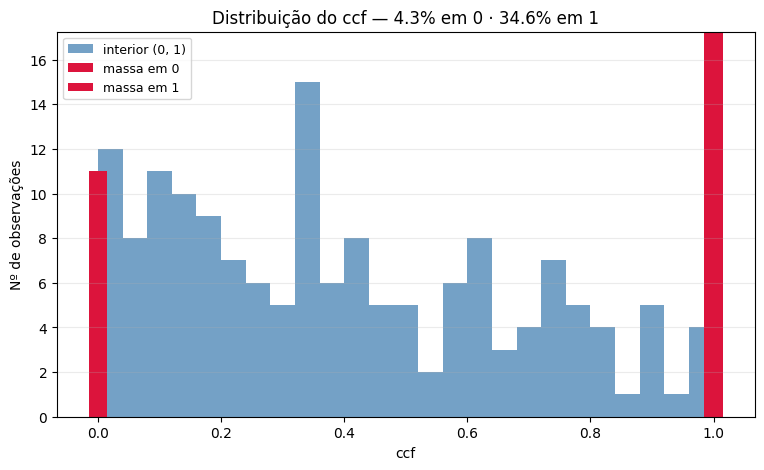

In [33]:
# A distribuição do CCF é bimodal: massa em 0 (não mexeu no limite) e em 1 (sacou tudo).
fig = base.plot()

In [34]:
from yggdrasil.credit_risk.ecl import pooled_ccf, backtest_ead, compare_measures

agrupado = pooled_ccf(base, by="produto", stat="weighted")
display(agrupado[["grupo", "n", "ccf", "ic_inf", "ic_sup", "massa_em_0", "massa_em_1"]].round(4))
print("CCF downturn (p90):", round(base.downturn(0.9), 4))

,grupo,n,ccf,ic_inf,ic_sup,massa_em_0,massa_em_1
0,cartao,168,0.5459,0.4939,0.5979,0.0060,0.4464
1,consignado,89,0.2561,0.1815,0.3307,0.1124,0.1573


CCF downturn (p90): 1.0


In [35]:
# O backtest compara EAD previsto e realizado EM MOEDA — um CCF com erro médio zero por
# contrato pode subestimar a carteira se errar justamente nos contratos grandes.
estimativas = {k: float(v) for k, v in zip(agrupado["grupo"], agrupado["ccf"])}
backtest_ead(base, estimativas, by="produto").round(4)

,grupo,n,ead_previsto,ead_realizado,vies,vies_relativo,erro_medio,mae,rmse,erro_absoluto_relativo,medida
0,__global__,257,999310.8374,997775.7228,1535.1145,0.0015,5.9732,802.6517,1147.0248,0.2067,ccf
1,cartao,168,713326.7177,713302.7451,23.9725,0.0000,0.1427,872.9699,1259.3694,0.2056,ccf
2,consignado,89,285984.1197,284472.9777,1511.1420,0.0053,16.9791,669.9161,897.4136,0.2096,ccf


In [36]:
# As quatro medidas ex-post no mesmo backtest — a comparação que a validação vai pedir.
compare_measures(base)[["medida", "vies_relativo", "erro_absoluto_relativo", "rmse"]].round(5)

,medida,vies_relativo,erro_absoluto_relativo,rmse
0,auf,-0.00033,0.19986,1045.06917
1,ccf,0.10341,0.25415,1418.32657
2,eadf,0.01186,0.35784,1805.56764
3,ead,0.00000,0.52512,2700.98821


> O ajuste **preditivo** (CCF em função de características do cliente) fica com o
> `ModelSegmenter(task_type="regression")` — a base que sai de `reference_dataset` já está
> no formato que ele consome.

---
## 8 · A montagem: `ecl_table`

$$ECL = \sum_t PD_{marginal}(t)\cdot LGD(t)\cdot EAD(t)\cdot (1+i)^{-t/12}$$

O estágio só corta o horizonte:

| estágio | tratamento |
|---|---|
| 1 | ECL de **12 meses** |
| 2 | ECL ***lifetime*** |
| 3 | ativo problemático: **ELBE** sobre o saldo atual |

**A regra de transferência (SICR) não está aqui** — é política da instituição. O módulo
recebe a coluna `estagio` pronta e faz a conta.

In [37]:
from yggdrasil.credit_risk.ecl import ecl_table, ead_schedule

# A exposição amortiza: tratar o EAD como constante superestima a provisão.
cronograma = ead_schedule(carteira["saldo"].to_numpy(), carteira["prazo"].to_numpy(),
                          horizon=48, method="linear")

res = ecl_table(carteira, model=lt_cal, lgd="lgd", ead=cronograma, exposure_col="saldo",
                stage_col="estagio", elbe="elbe", discount_rate="taxa_efetiva",
                age_col="idade", term_col="prazo")
res

ECLResult(n=1200, H=48, ECL=949,507.10, cobertura=9.03%)

In [38]:
res.summary().round(4)

,estagio,exposicao,ecl,ecl_12m,ecl_lifetime,n_contratos,taxa_provisao
0,1,7.554329e+06,67478.8510,67478.8510,73096.7465,847,0.0089
1,2,1.977477e+06,19395.7393,17794.5793,19395.7393,235,0.0098
2,3,9.785578e+05,862632.5075,9072.5983,9698.4283,118,0.8815


In [39]:
res.by("produto", "estagio").round(4)

,produto,estagio,exposicao,ecl,ecl_12m,ecl_lifetime,n_contratos,taxa_provisao
0,cartao,1,3.655917e+06,59545.6746,59545.6746,64170.5759,417,0.0163
1,cartao,2,9.319672e+05,16648.6625,15332.1483,16648.6625,112,0.0179
2,cartao,3,4.845333e+05,453536.0288,8144.7159,8609.5686,62,0.9360
3,consignado,1,3.898412e+06,7933.1763,7933.1763,8926.1707,430,0.0020
4,consignado,2,1.045509e+06,2747.0767,2462.4309,2747.0767,123,0.0026
5,consignado,3,4.940245e+05,409096.4787,927.8823,1088.8597,56,0.8281


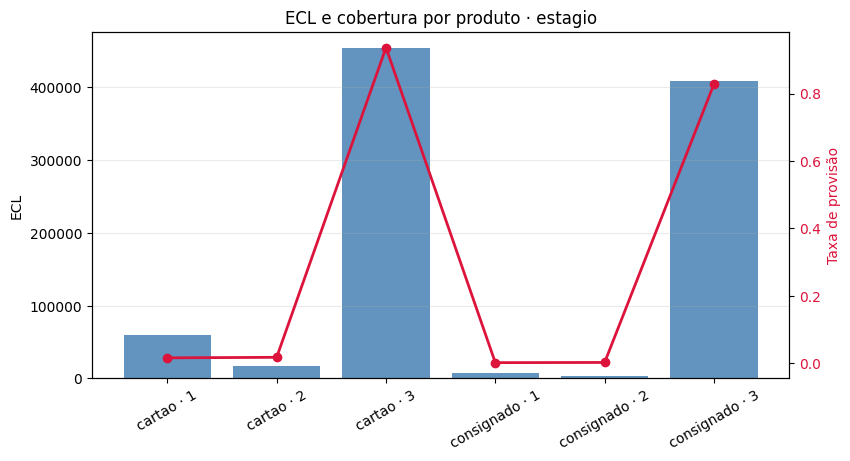

In [40]:
fig = report.plot_ecl_by(res, "produto", "estagio")

### Cenários — o *forward-looking*

O forward-looking de IFRS 9 / 4.966 é uma **média ponderada de cenários**, não o cenário
base com uma margem por cima. Os `z` podem vir de julgamento ou da projeção de um modelo
satélite de `credit_risk.econometric`.

In [41]:
from yggdrasil.credit_risk.ecl import ecl_scenarios

cen = ecl_scenarios(
    carteira, lt_cal,
    scenarios={
        "otimista": {"z": +1.0, "peso": 0.20},
        "base":     {"z":  0.0, "peso": 0.50},
        "adverso":  {"z": -1.5, "peso": 0.30, "decay": 0.10},
    },
    rho=0.10,
    lgd="lgd", ead=cronograma, exposure_col="saldo", stage_col="estagio", elbe="elbe",
    discount_rate="taxa_efetiva", age_col="idade", term_col="prazo",
)
display(cen["por_cenario"].round(2))
print(f"ECL ponderado: {cen['ponderado']:,.2f}   (base: {res.total:,.2f})")

,cenario,peso,ecl,exposicao,taxa_provisao,z,contribuicao
0,otimista,0.2,899390.79,10510363.33,0.09,1.0,179878.16
1,base,0.5,949507.10,10510363.33,0.09,0.0,474753.55
2,adverso,0.3,972576.51,10510363.33,0.09,-1.5,291772.95


ECL ponderado: 946,404.66   (base: 949,507.10)


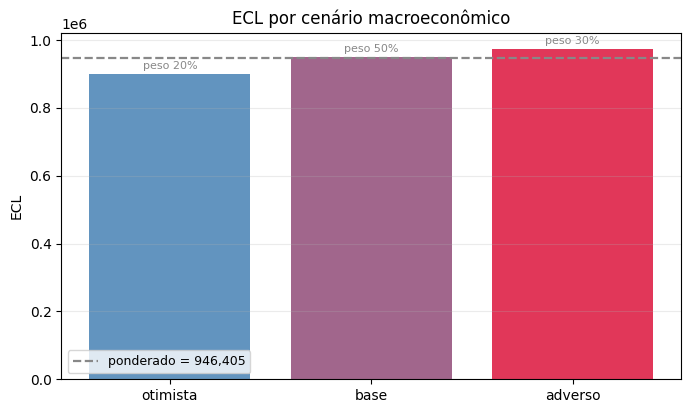

In [42]:
fig = report.plot_ecl_scenarios(cen)

---
## 9 · Governança: gráficos e MLflow

A provisão é auditada, e a auditoria precisa **reconstruir o número** a partir dos insumos
versionados: qual curva, qual calibração, qual cenário, qual data.

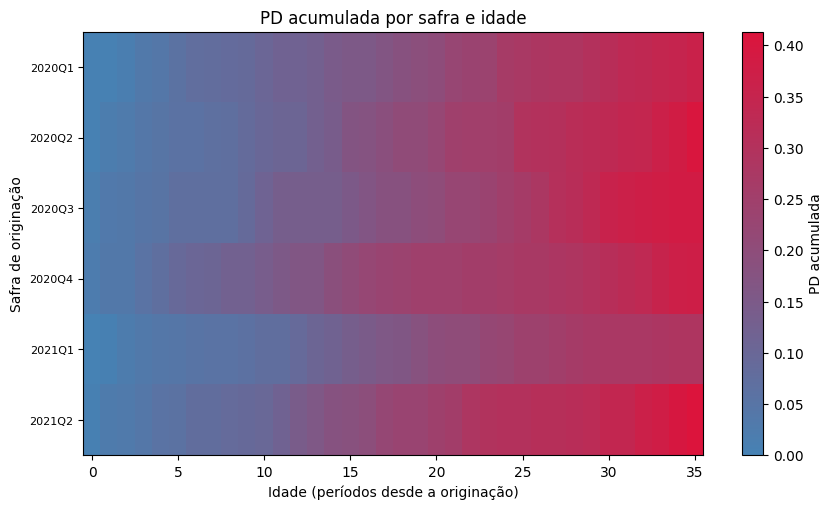

In [43]:
fig = report.plot_vintage_heatmap(painel, cohort_freq="Q")

In [44]:
import mlflow
from yggdrasil.credit_risk.ecl import log_lifetime_pd, log_elbe, log_ccf, log_ecl_run

mlflow.set_tracking_uri("file:./mlruns")
EXP = "/Shared/Yggdrasil/ecl_tutorial"

run_pd   = log_lifetime_pd(lt_cal, backtest=bt, experiment=EXP, run_name="pd_lifetime")
run_elbe = log_elbe(tab, experiment=EXP, run_name="elbe")
run_ccf  = log_ccf(base, pooled=agrupado, experiment=EXP, run_name="ccf")
run_ecl  = log_ecl_run(res, model=lt_cal, scenarios=cen, by=["produto"],
                       experiment=EXP, run_name="ecl_carteira")
print("runs:", run_pd[:8], run_elbe[:8], run_ccf[:8], run_ecl[:8])

2026/08/16 14:02:48 INFO mlflow.tracking.fluent: Experiment with name '/Shared/Yggdrasil/ecl_tutorial' does not exist. Creating a new experiment.


runs: fd4adf84 8a9be390 f39baf59 2baea9e0


In [45]:
# O modelo de PD serializa em JSON e volta idêntico — inclusive os ajustes aplicados.
from yggdrasil.credit_risk.ecl import LifetimePD

recarregado = LifetimePD.from_json(lt_cal.to_json())
print("curvas idênticas:", np.allclose(recarregado.curve("cartao").hazard_,
                                       lt_cal.curve("cartao").hazard_))
print("ajustes registrados:", [a["tipo"] for a in recarregado.adjustments_])

curvas idênticas: True
ajustes registrados: ['logit_shift']


---
## Resumo

| bloco | entrada | saída |
|---|---|---|
| **PD lifetime** | painel de contratos (`ContractPanel`) | `PDCurve` por grupo ou por contrato |
| **ELBE** | exposição inicial + colunas de LGD por mês | ELBE e LGD *in default* por tempo em *default* |
| **CCF** | painel de rotativos (sacado/limite) | CCF agrupado + *backtest* de EAD |
| **ECL** | os três acima + estágio + desconto | provisão por contrato, estágio e cenário |

**Os três erros que este subpacote existe para evitar:**

1. somar a PD **condicional** ou a **acumulada** no lugar da **marginal**;
2. tratar o não observado como zero — na curva de PD (censura) e na de recuperação
   (coorte variável);
3. reportar `1 − r̄(t)` como ELBE — isso é a LGD acumulada, retrospectiva, não a melhor
   estimativa do que ainda falta.

| aprofundamento por módulo | |
|---|---|
| [`13`](13_tutorial_pd_lifetime.ipynb) | **PD lifetime** — censura, as 4 representações da curva, os 5 motores, calibração de nível e condicionamento ao ciclo |
| [`14`](14_tutorial_elbe.ipynb) | **ELBE** — coorte variável, horizonte de *workout*, desconto, *add-on* e LGD *in default* |
| [`15`](15_tutorial_ccf.ipynb) | **CCF/EAD** — os 3 desenhos de base, as 4 medidas, higiene, bimodalidade, backtest e a ponte com o `ModelSegmenter` |

Este notebook é a **visão de conjunto**: percorre os três parâmetros e fecha na tabela de
ECL. Cada um deles tem um tutorial próprio, mais fundo, na tabela acima.

> Metodologia e referências da literatura: [`docs/credit-risk/ecl.md`](../../docs/credit-risk/ecl.md).